In [ ]:
#mount drive

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os
feature_dir = "/content/drive/MyDrive/TradionalOlives/RandomForestoliveTreeFeaturesWithoutSegmentation"
os.makedirs(feature_dir, exist_ok=True)

In [ ]:
!pip install scikit-image==0.19.3

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 49.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for scikit-image: filename=scikit_image-0.19.3-cp311-cp311-linux_x86_64.whl size=33913030 sha256=a73559d21b76096dc5a71cf2873a6e7b24cb8c01a755450f222926463be6f14e
  Stored in directory: /root/.cache/pip/wheels/7b/12/cd/f311cabf9e8708d1e29e9951ee0839fb89b69e1acc60c94927
Successfully built scikit-image
  Attempting uninstall: scikit-image
    Found existing installation: scikit-image 0.25.2
    Uninstalling scikit-image-0.25.2:
      Successfully uninstalled scikit-image-0.25.2


In [ ]:
!pip install -U scikit-image

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.8/14.8 MB 56.3 MB/s eta 0:00:00
  Attempting uninstall: scikit-image
    Found existing installation: scikit-image 0.19.3
    Uninstalling scikit-image-0.19.3:
      Successfully uninstalled scikit-image-0.19.3


In [ ]:

from skimage.feature import graycomatrix, graycoprops
from tqdm import tqdm

In [ ]:

import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt

In [ ]:
# Define paths

# Images folder paths (for feature extraction)
train_img_dir = "/content/drive/MyDrive/TradionalOlives/oliveTreeNewDataset/DatasetOlive/train"
valid_img_dir = "/content/drive/MyDrive/TradionalOlives/oliveTreeNewDataset/DatasetOlive/valid"
test_img_dir  = "/content/drive/MyDrive/TradionalOlives/oliveTreeNewDataset/DatasetOlive/test"

# CSV ground truth paths
train_csv = "/content/drive/MyDrive/TradionalOlives/oliveTreeRealdata/train_realdata.csv"
valid_csv = "/content/drive/MyDrive/TradionalOlives/oliveTreeRealdata/valid_realdata.csv"
test_csv  = "/content/drive/MyDrive/TradionalOlives/oliveTreeRealdata/test_realdata.csv"

In [ ]:
#  Read them into DataFrames
train_df = pd.read_csv(train_csv)
valid_df = pd.read_csv(valid_csv)
test_df  = pd.read_csv(test_csv)

#  Visual check
print("Train set:")
print(train_df.head())

print("\nValidation set:")
print(valid_df.head())

print("\nTest set:")
print(test_df.head())

Train set:
                                          image_path  yield_kg
0  /content/drive/MyDrive/TradionalOlives/oliveTr...      75.0
1  /content/drive/MyDrive/TradionalOlives/oliveTr...      78.0
2  /content/drive/MyDrive/TradionalOlives/oliveTr...      50.0
3  /content/drive/MyDrive/TradionalOlives/oliveTr...      55.0
4  /content/drive/MyDrive/TradionalOlives/oliveTr...      48.0

Validation set:
                                          image_path  yield_kg
0  /content/drive/MyDrive/TradionalOlives/oliveTr...      84.0
1  /content/drive/MyDrive/TradionalOlives/oliveTr...      70.0
2  /content/drive/MyDrive/TradionalOlives/oliveTr...      66.0
3  /content/drive/MyDrive/TradionalOlives/oliveTr...      40.0
4  /content/drive/MyDrive/TradionalOlives/oliveTr...      80.0

Test set:
                                          image_path  yield_kg
0  /content/drive/MyDrive/TradionalOlives/oliveTr...      72.0
1  /content/drive/MyDrive/TradionalOlives/oliveTr...      70.0
2  /content/driv

In [ ]:
#GLCM feature extractor function
def extract_glcm_features(img_path):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None
    img = cv2.resize(img, (224, 224))
    glcm = graycomatrix(img, distances=[1], angles=[0], levels=256, symmetric=True, normed=True)
    return [
        graycoprops(glcm, 'contrast')[0, 0],
        graycoprops(glcm, 'dissimilarity')[0, 0],
        graycoprops(glcm, 'homogeneity')[0, 0],
        graycoprops(glcm, 'energy')[0, 0],
        graycoprops(glcm, 'correlation')[0, 0]
    ]

In [ ]:
feature_dir ="/content/drive/MyDrive/TradionalOlives/RandomForestoliveTreeFeaturesWithoutSegmentation"

In [ ]:
# Dataset processing function
def process_dataset(csv_path, split_name):
    df = pd.read_csv(csv_path)
    features, labels = [], []

    print(f"Processing {split_name}...")
    for _, row in tqdm(df.iterrows(), total=len(df)):
        feats = extract_glcm_features(row['image_path'])
        if feats:
            features.append(feats)
            labels.append(row['yield_kg'])

    features_df = pd.DataFrame(features, columns=['contrast', 'dissimilarity', 'homogeneity', 'energy', 'correlation'])
    features_df['yield_kg'] = labels
    features_df.to_csv(os.path.join(feature_dir, f"{split_name}_features.csv"), index=False)
    return np.array(features), np.array(labels)

In [ ]:
# Extract features
X_train, y_train = process_dataset(train_csv, "train")
X_valid, y_valid = process_dataset(valid_csv, "valid")
X_test,  y_test  = process_dataset(test_csv, "test")

Processing train...


100%|██████████| 1265/1265 [10:34<00:00,  1.99it/s]


Processing valid...


100%|██████████| 14/14 [00:05<00:00,  2.48it/s]


Processing test...


100%|██████████| 15/15 [00:06<00:00,  2.46it/s]


In [ ]:
# Build ML pipeline
model_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', RandomForestRegressor(n_estimators=300, random_state=42))
])


In [ ]:
# Train on training set
model_pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('regressor',
                 RandomForestRegressor(n_estimators=300, random_state=42))])

In [ ]:
def evaluate(y_true, y_pred, title=""):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)  #  Manual square root instead of squared=False
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"\n {title} Performance:")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE : {mae:.2f}")
    print(f"R2  : {r2:.2f}")


In [ ]:

# Validation performance
valid_preds = model_pipeline.predict(X_valid)
evaluate(y_valid, valid_preds, "Validation Set")



📈 Validation Set Performance:
RMSE: 21.29
MAE : 17.69
R2  : -1.43


In [ ]:
# Test performance
test_preds = model_pipeline.predict(X_test)
evaluate(y_test, test_preds, "Test Set")


📈 Test Set Performance:
RMSE: 26.94
MAE : 23.59
R2  : -1.80


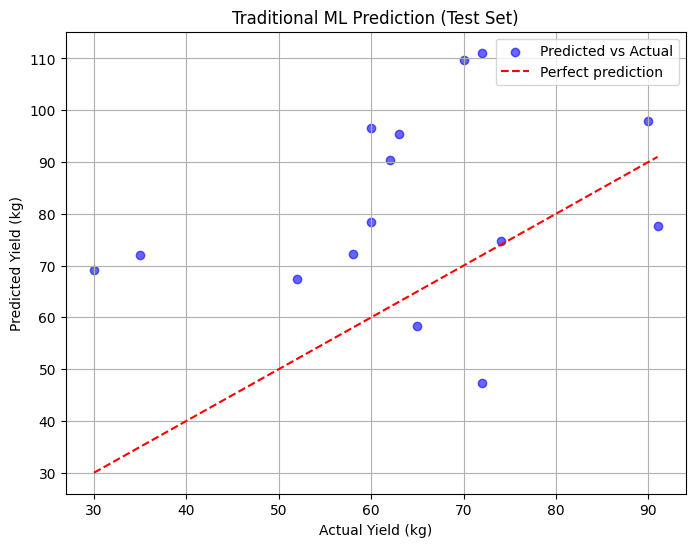

In [ ]:
# Scatter Plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test, test_preds, c='blue', alpha=0.6, label='Predicted vs Actual')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--', label='Perfect prediction')
plt.xlabel('Actual Yield (kg)')
plt.ylabel('Predicted Yield (kg)')
plt.title('Traditional ML Prediction (Test Set)')
plt.legend()
plt.grid(True)



In [ ]:
import pandas as pd

# Create DataFrame from your predictions
comparison_df = pd.DataFrame({
    'Real_Yield_kg': y_test,
    'Predicted_Yield_kg': test_preds
})

# Optional: Round values for cleaner display
comparison_df['Real_Yield_kg'] = comparison_df['Real_Yield_kg'].round(2)
comparison_df['Predicted_Yield_kg'] = comparison_df['Predicted_Yield_kg'].round(2)

# Show the table
print(" Real vs Predicted Yield (kg):")
print(comparison_df.head(50))  # Show first 10 rows



 Real vs Predicted Yield (kg):
    Real_Yield_kg  Predicted_Yield_kg
0            72.0              111.11
1            70.0              109.76
2            35.0               71.98
3            90.0               97.92
4            60.0               78.42
5            52.0               67.34
6            62.0               90.38
7            63.0               95.49
8            65.0               58.29
9            30.0               69.21
10           60.0               96.54
11           91.0               77.69
12           72.0               47.33
13           74.0               74.72
14           58.0               72.26
